In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\anami\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
# Load Dataset
df = pd.read_csv("dataset9/training_data.csv")

In [6]:
print(df.shape)
print(df.columns)
print(df.info())

(10000, 7)
Index(['Resume ID', 'Resume Text', 'Education', 'Experience Years', 'Skills',
       'Job Role', 'Category'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Resume ID         10000 non-null  object
 1   Resume Text       10000 non-null  object
 2   Education         10000 non-null  object
 3   Experience Years  10000 non-null  int64 
 4   Skills            10000 non-null  object
 5   Job Role          10000 non-null  object
 6   Category          10000 non-null  object
dtypes: int64(1), object(6)
memory usage: 547.0+ KB
None


In [7]:
print(df.isnull().sum())

Resume ID           0
Resume Text         0
Education           0
Experience Years    0
Skills              0
Job Role            0
Category            0
dtype: int64


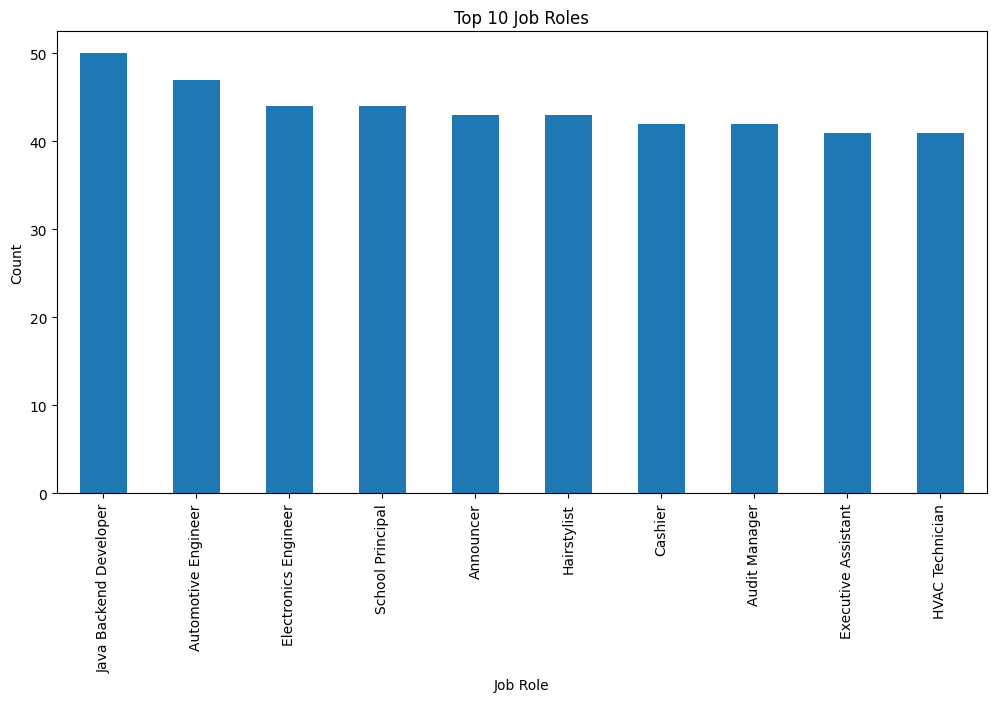

In [8]:
plt.figure(figsize=(12,6))
df['Job Role'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Job Roles")
plt.xlabel("Job Role")
plt.ylabel("Count")
plt.show()

In [9]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [10]:
df['Clean_Resume'] = df['Resume Text'].apply(clean_text)

print(df[['Resume Text', 'Clean_Resume']].head())

                                         Resume Text  \
0  Education: Bachelor's in Computer Science Expe...   
1  Education: Master's in Microbiology Experience...   
2  Education: Apprenticeship Experience: 2 years ...   
3  Education: Bachelor's in Computer Science Expe...   
4  Education: Bachelor's in Design Experience: 3 ...   

                                        Clean_Resume  
0  education bachelors computer science experienc...  
1  education masters microbiology experience year...  
2  education apprenticeship experience years skil...  
3  education bachelors computer science experienc...  
4  education bachelors design experience years sk...  


In [11]:
label_encoder = LabelEncoder()

df['Job_Label'] = label_encoder.fit_transform(df['Job Role'])

In [12]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['Clean_Resume'])
y = df['Job_Label']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [15]:
y_pred = model.predict(X_test)

In [16]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.99


In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.86      0.92         7
           2       0.83      1.00      0.91         5
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         4
           5       0.91      1.00      0.95        10
           6       1.00      1.00      1.00         6
           7       1.00      0.83      0.91         6
           8       1.00      1.00      1.00        11
           9       1.00      1.00      1.00         7
          10       1.00      1.00      1.00         8
          11       1.00      1.00      1.00         7
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00        12
          14       1.00      1.00      1.00         5
          15       1.00      1.00      1.00         5
          16       1.00      1.00      1.00         9
          17       1.00    

In [18]:
sample_resume = """
Python developer with machine learning, deep learning,
TensorFlow, Flask, NLP, SQL and data analysis skills.
Worked on AI projects and web applications.
"""

# Clean text
clean_resume = clean_text(sample_resume)

# Convert to vector
resume_vector = vectorizer.transform([clean_resume])

# Predict
prediction = model.predict(resume_vector)

# Decode label
predicted_role = label_encoder.inverse_transform(prediction)

print("Predicted Job Role:", predicted_role[0])

Predicted Job Role: Data Scientist


In [23]:
skills_list = pd.read_csv("dataset9/skills_list.csv")

# First column automatically select
all_skills = skills_list.iloc[:, 0].dropna().tolist()

resume_text = sample_resume.lower()

found_skills = []

for skill in all_skills:
    if str(skill).lower() in resume_text:
        found_skills.append(skill)

print("Extracted Skills:")
print(found_skills)

Extracted Skills:
['Python', 'R', 'Flask', 'Machine Learning', 'Deep Learning', 'TensorFlow', 'Data Analysis', 'SQL', 'Python', 'R', 'SQL']


In [24]:
required_skills = ['Python', 'Machine Learning', 'SQL', 'Deep Learning']

matched = 0

for skill in required_skills:
    if skill.lower() in resume_text:
        matched += 1

score = (matched / len(required_skills)) * 100

print("Resume Match Score:", score)

Resume Match Score: 100.0


In [25]:
import pickle

pickle.dump(model, open('resume_model.pkl', 'wb'))
pickle.dump(vectorizer, open('tfidf_vectorizer.pkl', 'wb'))
pickle.dump(label_encoder, open('label_encoder.pkl', 'wb'))

print("Model Saved Successfully")

Model Saved Successfully


In [26]:
# Example rule-based detection

def fake_resume_detector(text):

    suspicious_words = [
        'guaranteed',
        '100% success',
        'fake experience',
        'dummy project'
    ]

    for word in suspicious_words:
        if word in text.lower():
            return "Suspicious Resume"

    return "Normal Resume"


print(fake_resume_detector(sample_resume))

Normal Resume


In [27]:
# Resume Analysis Function

def analyze_resume(resume_text):

    strengths = []
    weaknesses = []
    suggestions = []

    text = resume_text.lower()

    # Skills Check
    good_skills = [
        'python',
        'machine learning',
        'deep learning',
        'sql',
        'nlp',
        'opencv',
        'tensorflow',
        'power bi'
    ]

    found_skills = []

    for skill in good_skills:
        if skill in text:
            found_skills.append(skill)

    # Strengths
    if len(found_skills) >= 5:
        strengths.append("Strong technical skill set")

    if 'project' in text:
        strengths.append("Projects are included")

    if 'certification' in text or 'certifications' in text:
        strengths.append("Certifications added")

    if 'internship' in text:
        strengths.append("Internship experience available")

    # Weaknesses
    if 'github' not in text:
        weaknesses.append("GitHub profile missing")

    if 'linkedin' not in text:
        weaknesses.append("LinkedIn profile missing")

    if 'experience' not in text:
        weaknesses.append("Industry experience missing")

    if len(found_skills) < 3:
        weaknesses.append("Technical skills are limited")

    # Suggestions
    if 'github' not in text:
        suggestions.append("Add GitHub project links")

    suggestions.append("Add more measurable achievements")

    suggestions.append("Keep resume to 1 page for fresher roles")

    suggestions.append("Customize resume according to job role")

    # Resume Score
    score = 50 + (len(found_skills) * 5)

    if score > 100:
        score = 100

    # Print Results
    print("========== Resume Analysis ==========")

    print("\nResume Score:", score, "/100")

    print("\nStrengths:")
    for s in strengths:
        print("✅", s)

    print("\nWeaknesses:")
    for w in weaknesses:
        print("❌", w)

    print("\nSuggestions:")
    for sug in suggestions:
        print("📌", sug)

    print("\nDetected Skills:")
    print(found_skills)

In [29]:
!pip install PyPDF2


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import PyPDF2

pdf_path = "resume.pdf"

text = ""

with open(pdf_path, "rb") as file:
    reader = PyPDF2.PdfReader(file)

    for page in reader.pages:
        text += page.extract_text()

analyze_resume(text)

========== Resume Analysis ==========

Resume Score: 90 /100

Strengths:
✅ Strong technical skill set
✅ Projects are included
✅ Certifications added
✅ Internship experience available

Weaknesses:
❌ Industry experience missing

Suggestions:
📌 Add more measurable achievements
📌 Keep resume to 1 page for fresher roles
📌 Customize resume according to job role

Detected Skills:
['python', 'machine learning', 'deep learning', 'sql', 'nlp', 'opencv', 'tensorflow', 'power bi']
